In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
count = 0
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
        count += 1
        if count > 10:
            break
    break

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Importing Libraries

In [2]:
import os
import pandas as pd
import numpy as np
from PIL import Image
import cv2

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.utils.data import WeightedRandomSampler

import torch.nn.functional as F
import torchvision.transforms as transforms
import torchvision.models as models

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix


from tqdm import tqdm

from torchvision.models import densenet121, DenseNet121_Weights



torch.backends.cudnn.benchmark = True

# Check GPU

In [3]:
print("GPU Available:", torch.cuda.is_available())
print("GPU Name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

GPU Available: True
GPU Name: Tesla T4


# Load Datasets

In [4]:
train_df = pd.read_csv('/kaggle/input/competitions/26-t-1-dl-gen-ainppe-1/train.csv')
test_df = pd.read_csv('/kaggle/input/competitions/26-t-1-dl-gen-ainppe-1/test.csv')

IMG_DIR = '/kaggle/input/competitions/26-t-1-dl-gen-ainppe-1/images'

train_df.head()

,id,Atelectasis,Cardiomegaly,Consolidation,Edema,Effusion,Emphysema,Fibrosis,Hernia,Infiltration,...,Nodule,Pleural_Thickening,Pneumonia,Pneumothorax,Pneumoperitoneum,Pneumomediastinum,Subcutaneous Emphysema,Tortuous Aorta,Calcification of the Aorta,No Finding
0,977df638b5294072ac81c369e2d9ecd0.png,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,4f6dd5e39cd548df904b7319b13a40c5.png,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,8772d25762484c2aa3f3e124d2ebcb30.png,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,31caeb0fa0814858bf4591bc1c8d63ac.png,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,9cd3df7acfbf4bb8a00466801469b08b.png,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [5]:
print(train_df.shape)
print(test_df.shape)

(51043, 21)
(17015, 1)


# Goal

**Predict correct pathology for each image.**


# Encoding

In [6]:
label_cols = train_df.columns[1:]
train_df['label'] = train_df[label_cols].values.argmax(axis=1)

train_df[['id', 'label']].head()

,id,label
0,977df638b5294072ac81c369e2d9ecd0.png,19
1,4f6dd5e39cd548df904b7319b13a40c5.png,19
2,8772d25762484c2aa3f3e124d2ebcb30.png,0
3,31caeb0fa0814858bf4591bc1c8d63ac.png,19
4,9cd3df7acfbf4bb8a00466801469b08b.png,19


In [7]:
no_finding_idx = list(label_cols).index('No Finding')
print(f"No Finding Index: {no_finding_idx}")

No Finding Index: 19


# Feature Distribution

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

label_counts = train_df['label'].value_counts().sort_index()

class_names = list(label_cols)
distribution_df = pd.DataFrame({
    'Pathology': class_names,
    'Count': [label_counts.get(i, 0) for i in range(len(class_names))]
})

distribution_df['Percentage (%)'] = (distribution_df['Count'] / len(train_df) * 100).round(2)

print("--- Class Distribution (Sorted by Rarity) ---")
print(distribution_df.sort_values(by='Count').to_string(index=False))

--- Class Distribution (Sorted by Rarity) ---
                 Pathology  Count  Percentage (%)
         Pneumomediastinum      5            0.01
    Subcutaneous Emphysema     24            0.05
                    Hernia     37            0.07
          Pneumoperitoneum     44            0.09
Calcification of the Aorta     91            0.18
                 Pneumonia    160            0.31
                 Emphysema    172            0.34
            Tortuous Aorta    254            0.50
                     Edema    326            0.64
                  Fibrosis    389            0.76
              Cardiomegaly    600            1.18
        Pleural_Thickening    608            1.19
             Consolidation    651            1.28
              Pneumothorax   1114            2.18
                      Mass   1249            2.45
                    Nodule   1527            2.99
                  Effusion   2156            4.22
               Atelectasis   2351            4.61
    

/tmp/ipykernel_24/703180452.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Count', y='Pathology', data=distribution_df.sort_values(by='Count', ascending=False), palette='viridis')


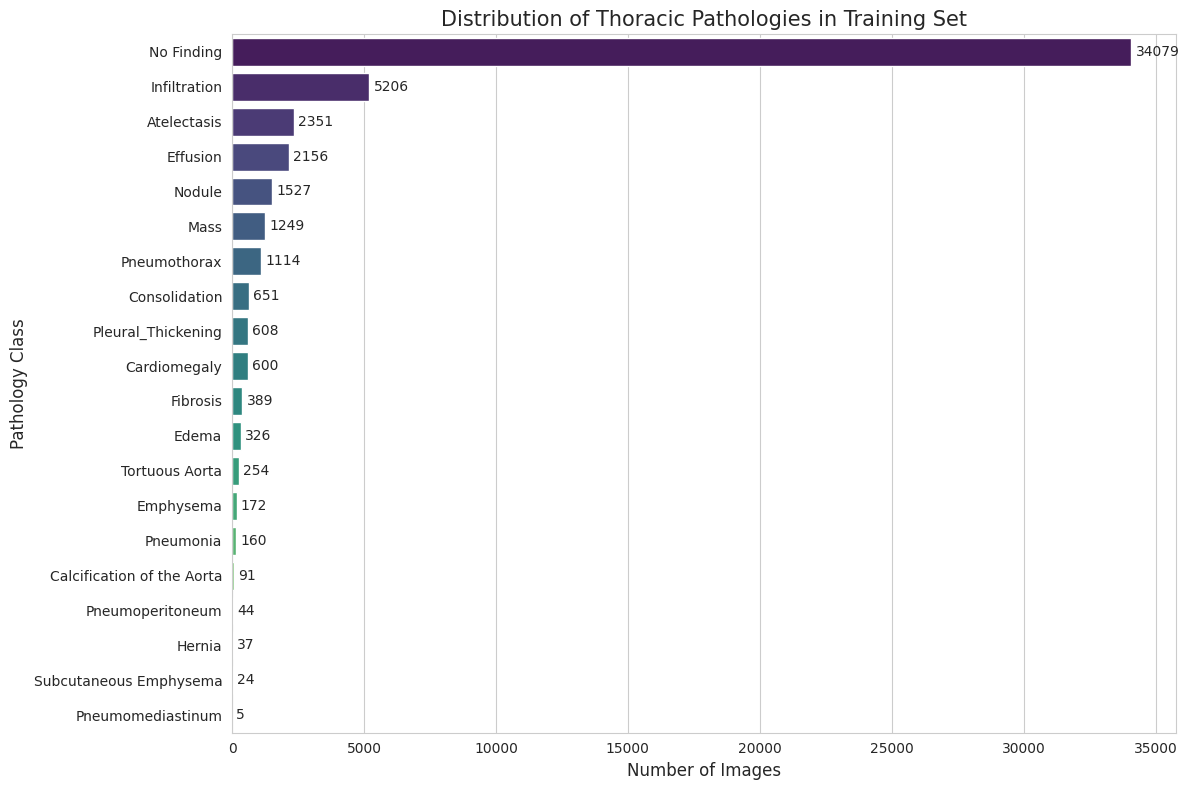

In [9]:
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

# Create the bar plot
ax = sns.barplot(x='Count', y='Pathology', data=distribution_df.sort_values(by='Count', ascending=False), palette='viridis')

# Add labels and title
plt.title('Distribution of Thoracic Pathologies in Training Set', fontsize=15)
plt.xlabel('Number of Images', fontsize=12)
plt.ylabel('Pathology Class', fontsize=12)

# Add count labels on the bars
for i in ax.containers:
    ax.bar_label(i, padding=3)

plt.tight_layout()
plt.show()

# Train/Validation Split

In [10]:
train_df, val_df = train_test_split(
                        train_df,
                        test_size=0.1,
                        stratify=train_df['label'],
                        random_state=4524
                    )

# Code

In [11]:
class XrayDataset(Dataset):
    def __init__(self, df, img_dir, transform=None, is_test=False):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform
        self.is_test = is_test
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        img_name = self.df.iloc[idx]['id']
        img_path = os.path.join(self.img_dir, img_name)
        
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
        
        if self.is_test:
            return image, img_name
        
        label = self.df.iloc[idx]['label']
        return image, label

# Transformers

In [12]:
class ApplyCLAHE(object):
    def __call__(self, img):
        img_np = np.array(img)
        gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        cl1 = clahe.apply(gray)
        return Image.fromarray(cv2.cvtColor(cl1, cv2.COLOR_GRAY2RGB))


In [13]:
train_transform = transforms.Compose([
                    ApplyCLAHE(),
                    transforms.Resize((224,224)),
                    transforms.RandomHorizontalFlip(),
                    transforms.RandomAffine(degrees=10, translate=(0.1, 0.1), scale=(0.9, 1.1)),
                    transforms.ToTensor(),
                    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
                ])
                
val_transform = transforms.Compose([
                    ApplyCLAHE(),
                    transforms.Resize((224,224)),
                    transforms.ToTensor(),
                    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
                ])

# DataLoaders

In [14]:
BATCH_SIZE = 128
num_workers = 4

train_dataset = XrayDataset(train_df, IMG_DIR, train_transform)
val_dataset   = XrayDataset(val_df, IMG_DIR, val_transform)
test_dataset  = XrayDataset(test_df, IMG_DIR, val_transform, is_test=True)

# 1. Calculate class counts from your training data
# Each image belongs to exactly one class [cite: 113]
class_counts = train_df['label'].value_counts().sort_index().values
class_weights = 1. / class_counts

# 2. Assign a weight to every individual sample in the training set
# Rare classes get a high weight; common classes get a low weight
sample_weights = [class_weights[label] for label in train_df['label']]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# 3. Update the DataLoader to use the sampler
train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    sampler=sampler,
    shuffle = False,
    num_workers=num_workers, 
    pin_memory=True
)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, num_workers=num_workers, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, num_workers=num_workers)

# Model - DenseNet121

In [15]:
model = densenet121(weights=DenseNet121_Weights.DEFAULT)

model.classifier = nn.Linear(model.classifier.in_features, 20)
model = model.to(device)

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 173MB/s]


# Loss + Optimizer + AMP

In [16]:
EPOCHS = 10
val = 1
alpha = 1.5

In [17]:
class AsymmetricCostLoss(nn.Module):
    def __init__(self, no_finding_idx, alpha=alpha):
        super(AsymmetricCostLoss, self).__init__()
        self.no_finding_idx = no_finding_idx
        self.alpha = alpha

    def forward(self, inputs, targets):
        log_probs = F.log_softmax(inputs, dim=1)
        probs = torch.exp(log_probs)
        
        # Standard Cross Entropy part
        loss = F.nll_loss(log_probs, targets, reduction='none')
        
        # Custom Penalty logic:
        # If the true label is NOT 'No Finding' (patient has disease)
        # but the model predicts 'No Finding', we apply alpha penalty.
        is_disease = (targets != self.no_finding_idx)
        pred_no_finding = (torch.argmax(inputs, dim=1) == self.no_finding_idx)
        
        # Apply extra weight to those specific False Negatives
        penalty_mask = is_disease & pred_no_finding
        loss[penalty_mask] *= self.alpha
        
        return loss.mean()

criterion = AsymmetricCostLoss(no_finding_idx=no_finding_idx, alpha=alpha)
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

# Training Function

In [18]:
scaler = torch.amp.GradScaler("cuda")

In [19]:
def train_one_epoch(model, loader):
    model.train()
    total_loss = 0
    
    for images, labels in tqdm(loader):
        images = images.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        
        with torch.amp.autocast(device_type='cuda'):
            outputs = model(images)
            loss = criterion(outputs, labels)
        
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        total_loss += loss.item()
    
    return total_loss / len(loader)

# Validation

In [20]:
def validate(model, loader):
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)

            probs[:, no_finding_idx] *= val 
            
            preds = torch.argmax(probs, dim=1)
            
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    
    return correct / total

# Training Loop

In [21]:
best_acc = 0
patience = 5
counter = 0

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model, train_loader)
    val_acc = validate(model, val_loader)

    scheduler.step()

    print(f"Epoch {epoch+1}: Loss={train_loss:.4f}, Val Acc={val_acc:.4f}")

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), "best_model.pth")
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print("Early stopping triggered")
        break

100%|██████████| 359/359 [05:30<00:00,  1.08it/s]


Epoch 1: Loss=2.6061, Val Acc=0.1287


100%|██████████| 359/359 [04:52<00:00,  1.23it/s]


Epoch 2: Loss=1.9761, Val Acc=0.1667


100%|██████████| 359/359 [04:54<00:00,  1.22it/s]


...

Epoch 8: Loss=1.0907, Val Acc=0.2182


100%|██████████| 359/359 [04:48<00:00,  1.24it/s]


Epoch 9: Loss=1.0875, Val Acc=0.2043


100%|██████████| 359/359 [04:52<00:00,  1.23it/s]


Epoch 10: Loss=1.0739, Val Acc=0.2071


In [22]:
def find_best_threshold(model, loader, device):
    model.eval()
    all_logits, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            all_logits.append(model(images.to(device)).cpu())
            all_labels.append(labels)
            
    probs_base = torch.softmax(torch.cat(all_logits), dim=1)
    labels = torch.cat(all_labels).numpy()
    thresholds = [1.0, 1.5, 2.0, 3.0, 5.0, 8.0, 10.0, 15.0, 20.0, 30.0, 50.0, 100.0]
    results = []

    for t in thresholds:
        temp_probs = probs_base.clone()
        temp_probs[:, 19] *= t 
        preds = torch.argmax(temp_probs, dim=1).numpy()
        cm = confusion_matrix(labels, preds, labels=list(range(20)))
        
        scores = []
        for c in range(20):
            tp, n_c = cm[c, c], cm[c, :].sum()
            fp, fn = cm[:, c].sum() - tp, n_c - tp
            if n_c > 0: scores.append((tp - fp - 5 * fn) / n_c)
        
        avg_score = np.mean(scores)
        results.append((t, avg_score))
        print(f"Handicap {t:.2f} -> Macro Score: {avg_score:.4f}")

    best_t, _ = max(results, key=lambda x: x[1])
    return best_t

winning_threshold = find_best_threshold(model, val_loader, device)
print(f"\n--- WINNING THRESHOLD: {winning_threshold} ---")

Handicap 1.00 -> Macro Score: -7.1450
Handicap 1.50 -> Macro Score: -6.8067
Handicap 2.00 -> Macro Score: -6.5167
Handicap 3.00 -> Macro Score: -5.9781
Handicap 5.00 -> Macro Score: -5.4493
Handicap 8.00 -> Macro Score: -5.1652
Handicap 10.00 -> Macro Score: -5.0278
Handicap 15.00 -> Macro Score: -4.9287
Handicap 20.00 -> Macro Score: -4.8305
Handicap 30.00 -> Macro Score: -4.8311
Handicap 50.00 -> Macro Score: -4.7646
Handicap 100.00 -> Macro Score: -4.7656

--- WINNING THRESHOLD: 50.0 ---


# Predictions

In [23]:
if os.path.exists("best_model.pth"):
    model.load_state_dict(torch.load("best_model.pth"))
    print("Loaded best_model.pth")

model.eval()
predictions = []

with torch.no_grad():
    for images, ids in tqdm(test_loader, desc="Predicting"):
        images = images.to(device)
        
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        
        probs[:, no_finding_idx] *= winning_threshold
        pred_classes = probs.argmax(dim=1).cpu().numpy()
        
        for i, img_id in enumerate(ids):
            row = [0] * 20
            row[pred_classes[i]] = 1
            predictions.append([img_id] + row)

Loaded best_model.pth


Predicting: 100%|██████████| 133/133 [01:46<00:00,  1.25it/s]


In [24]:
def get_competition_score(model, loader, device, num_classes=20):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            
            probs = torch.softmax(outputs, dim=1)
            probs[:, no_finding_idx] *= winning_threshold 
            
            preds = torch.argmax(probs, dim=1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            
    cm = confusion_matrix(all_labels, all_preds, labels=list(range(num_classes)))
    class_scores = []
    
    for c in range(num_classes):
        tp = cm[c, c]
        fp = cm[:, c].sum() - tp
        fn = cm[c, :].sum() - tp
        n_c = cm[c, :].sum()
        
        if n_c > 0:
            score_c = (tp - fp - 5 * fn) / n_c
            class_scores.append(score_c)
        else:
            class_scores.append(0.0)
            
    macro_score = np.mean(class_scores)
    return macro_score, class_scores

In [25]:
final_val_score, individual_scores = get_competition_score(model, val_loader, device)

print(f"Final Macro-Averaged Score: {final_val_score:.4f}")

for i, col in enumerate(label_cols):
    print(f"{col}: {individual_scores[i]:.4f}")

Final Macro-Averaged Score: -4.7707
Atelectasis: -5.0000
Cardiomegaly: -4.4167
Consolidation: -5.0000
Edema: -5.1212
Effusion: -4.8380
Emphysema: -5.1176
Fibrosis: -5.2821
Hernia: -5.2500
Infiltration: -5.0000
Mass: -4.7600
Nodule: -4.9608
Pleural_Thickening: -5.0000
Pneumonia: -5.0625
Pneumothorax: -4.6577
Pneumoperitoneum: -5.5000
Pneumomediastinum: -5.0000
Subcutaneous Emphysema: -5.0000
Tortuous Aorta: -5.8400
Calcification of the Aorta: -5.0000
No Finding: 0.3920


# Submission

In [26]:
submission = pd.DataFrame(predictions, columns=['id'] + list(label_cols))
submission.to_csv('submission.csv', index=False)

print("Submission file created!")

Submission file created!
